# Chapter 6 – Sharing and Dissemination of Images

This notebook explores two kinds of **visual sharing** in the Sphaera corpus:

1. **Exact-copy dissemination** – using `cluster_name`, which groups physically identical image copies.
2. **Thematic similarity** – using `cks` (Content Keywords), comparing books by their shared keyword profiles via cosine similarity.

Key questions:
- How did exact image copies spread across places and time?
- Were copies shared across long distances?
- Did these patterns change over time?
- How does thematic/keyword similarity compare to exact-copy sharing?

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from itertools import combinations
from math import radians, cos, sin, asin, sqrt

# Pure-numpy helpers (no sklearn required)
def cosine_similarity_matrix(matrix):
    """Row-wise cosine similarity for a 2d numpy array."""
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms[norms == 0] = 1e-10
    normed = matrix / norms
    return normed @ normed.T

class MultiLabelBinarizer:
    """Minimal replacement for sklearn.preprocessing.MultiLabelBinarizer."""
    def __init__(self): self.classes_ = None
    def fit_transform(self, lists):
        all_labels = sorted(set(lbl for sublist in lists for lbl in sublist))
        self.classes_ = np.array(all_labels)
        idx = {l: i for i, l in enumerate(all_labels)}
        mat = np.zeros((len(lists), len(all_labels)), dtype=np.float32)
        for row, sublist in enumerate(lists):
            for lbl in sublist:
                mat[row, idx[lbl]] = 1.0
        return mat

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [116]:
img_df = pd.read_csv('/Users/nogashlomi/projects/Image_data/dissertation/full_image_data_feb_25.csv')
book_df = pd.read_csv('/Users/nogashlomi/projects/Image_data/dissertation/full_book_data_feb_25.csv')

print('Image data:', img_df.shape)
print('Book data:', book_df.shape)
img_df.head(3)

Image data: (27981, 17)
Book data: (359, 11)


,images,cluster_name,cks,book,bid,part_or_adaption,part_or_adaption_label,type_label,custom_identifier,place,year,flag,year_interval,place_category,latitude,longitude,part_type
0,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,SAC_SIL_00803,CK_Populated Earth,http://sphaera.mpiwg-berlin.mpg.de/id/item/0be...,1924,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Anonymous commentary (foeliciter inchoat),"Content, Annotated",322.0,Venice,1488,NaN,1470-1489,Large Center,45.437191,12.33459,adaption_100
1,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,SAC_SIL_00803,CK_Lunar Eclipse,http://sphaera.mpiwg-berlin.mpg.de/id/item/0be...,1924,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Anonymous commentary (foeliciter inchoat),"Content, Annotated",322.0,Venice,1488,NaN,1470-1489,Large Center,45.437191,12.33459,adaption_100
2,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,SAC_SIL_00664,CK_Circles of Equant Deferent Epicycle,http://sphaera.mpiwg-berlin.mpg.de/id/item/0be...,1924,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Anonymous commentary (foeliciter inchoat),"Content, Annotated",322.0,Venice,1488,NaN,1470-1489,Large Center,45.437191,12.33459,adaption_100


In [117]:
# Basic overview
print('Unique cluster_names (exact copies):', img_df['cluster_name'].nunique())
print('Unique CKs:', img_df['cks'].nunique())
print('Unique places:', img_df['place'].nunique())
print('Year range:', img_df['year'].min(), '-', img_df['year'].max())
print('Year intervals:', sorted(img_df['year_interval'].dropna().unique()))

Unique cluster_names (exact copies): 3563
Unique CKs: 168
Unique places: 42
Year range: 1472 - 1647
Year intervals: ['1470-1489', '1490-1509', '1510-1529', '1530-1549', '1550-1569', '1570-1589', '1590-1609', '1610-1629', '1630-1650']


## 2. Exact-Copy Dissemination (cluster_name)

### 2a. Which clusters appear in more than one place?

In [118]:
# Deduplicate: one row per (cluster_name, book/bid) so we have the unique cluster-book combinations.
# Since one image row can carry multiple cks, collapse to unique image-book entries first.
img_unique = img_df.drop_duplicates(subset=['images', 'cluster_name', 'bid'])

# For each cluster, how many distinct places appear?
cluster_places = (
    img_unique.groupby('cluster_name')
    .agg(
        n_books=('bid', 'nunique'),
        n_places=('place', 'nunique'),
        places=('place', lambda x: sorted(x.dropna().unique().tolist())),
        year_min=('year', 'min'),
        year_max=('year', 'max'),
        year_span=('year', lambda x: x.max() - x.min())
    )
    .reset_index()
)

print('Clusters appearing in >1 place:', (cluster_places['n_places'] > 1).sum())
print('Clusters appearing in only 1 place:', (cluster_places['n_places'] == 1).sum())
cluster_places.sort_values('n_places', ascending=False).head(10)

Task was destroyed but it is pending!
task: <Task pending name='Task-515' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-516' coro=<Kernel.shell_main() running at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/pandas/core/generic.py:6286: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  for name in set(self._metadata) & set(other._metadata):
Task was destroyed but it is pending!
task: <Task pending name='Task-516' coro=<Kernel.shell_main() running at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-pa

Clusters appearing in >1 place: 854
Clusters appearing in only 1 place: 2709


,cluster_name,n_books,n_places,places,year_min,year_max,year_span
2094,SAC_SIL_02198,119,13,"[Antwerp, Coimbra, Cologne, Heidelberg, Ingols...",1526,1629,103
153,SAC_SIL_00155,100,13,"[Antwerp, Coimbra, Cologne, Heidelberg, Ingols...",1526,1629,103
1934,SAC_SIL_02026,108,12,"[Antwerp, Cologne, Ingolstadt, Leipzig, Leuven...",1526,1629,103
1855,SAC_SIL_01943,30,11,"[Antwerp, Cologne, Frankfurt (Main), Kraków, L...",1522,1629,107
1462,SAC_SIL_01506,131,11,"[Antwerp, Cologne, Ingolstadt, Leipzig, Leuven...",1526,1629,103
1114,SAC_SIL_01142,117,11,"[Antwerp, Cologne, Heidelberg, Ingolstadt, Leu...",1526,1629,103
1883,SAC_SIL_01971,60,11,"[Antwerp, Ferrara, Leipzig, Lisbon, London, Ly...",1472,1630,158
951,SAC_SIL_00975,85,11,"[Alcalá de Henares, Cologne, Heidelberg, Krakó...",1485,1607,122
1010,SAC_SIL_01034,122,11,"[Antwerp, Cologne, Heidelberg, Ingolstadt, Lei...",1526,1629,103
443,SAC_SIL_00455,115,10,"[Antwerp, Cologne, Ingolstadt, Leipzig, Leuven...",1526,1629,103


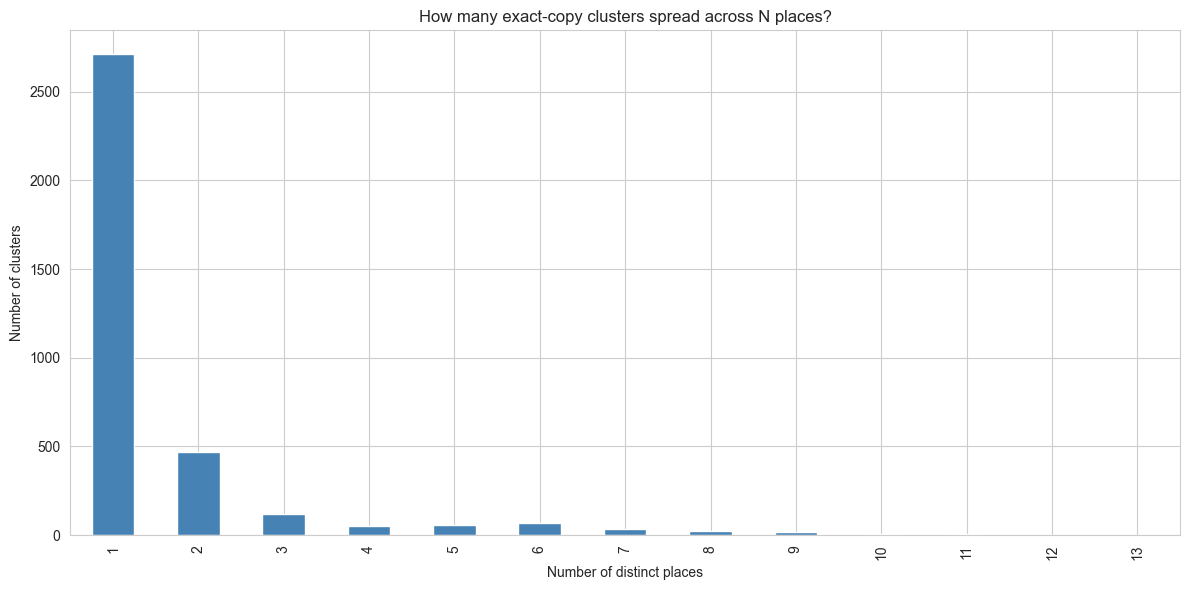

In [119]:
# Distribution: how many clusters by number of distinct places
fig, ax = plt.subplots()
cluster_places['n_places'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Number of distinct places')
ax.set_ylabel('Number of clusters')
ax.set_title('How many exact-copy clusters spread across N places?')
plt.tight_layout()
plt.show()

### 2b. Geographic distance between places sharing the same cluster

In [120]:
def haversine(lat1, lon1, lat2, lon2):
    """Return distance in km between two lat/lon points."""
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

# Build a place→coords lookup from the image data
place_coords = (
    img_unique[['place', 'latitude', 'longitude']]
    .dropna(subset=['latitude', 'longitude'])
    .drop_duplicates('place')
    .set_index('place')
)

# For multi-place clusters compute all pairwise distances
rows = []
multi_place_clusters = cluster_places[cluster_places['n_places'] > 1]

for _, row in multi_place_clusters.iterrows():
    cluster = row['cluster_name']
    places = [p for p in row['places'] if p in place_coords.index]
    for p1, p2 in combinations(places, 2):
        lat1, lon1 = place_coords.loc[p1, ['latitude', 'longitude']]
        lat2, lon2 = place_coords.loc[p2, ['latitude', 'longitude']]
        dist = haversine(lat1, lon1, lat2, lon2)
        rows.append({'cluster_name': cluster, 'place1': p1, 'place2': p2,
                     'distance_km': dist, 'year_min': row['year_min'],
                     'year_max': row['year_max'], 'year_span': row['year_span']})

pair_distances = pd.DataFrame(rows)
print('Pairwise place-pair sharing events:', len(pair_distances))
pair_distances.describe()

Pairwise place-pair sharing events: 5336


,distance_km,year_min,year_max,year_span
count,5336.000000,5336.000000,5336.000000,5336.000000
mean,675.152300,1538.617316,1612.124438,73.507121
std,402.165954,31.235462,26.139584,32.975756
min,36.138786,1472.000000,1480.000000,1.000000
25%,397.563090,1526.000000,1607.000000,48.000000
50%,597.127597,1537.000000,1618.000000,82.000000
75%,844.485731,1570.000000,1629.000000,103.000000
max,10040.243261,1606.000000,1647.000000,158.000000


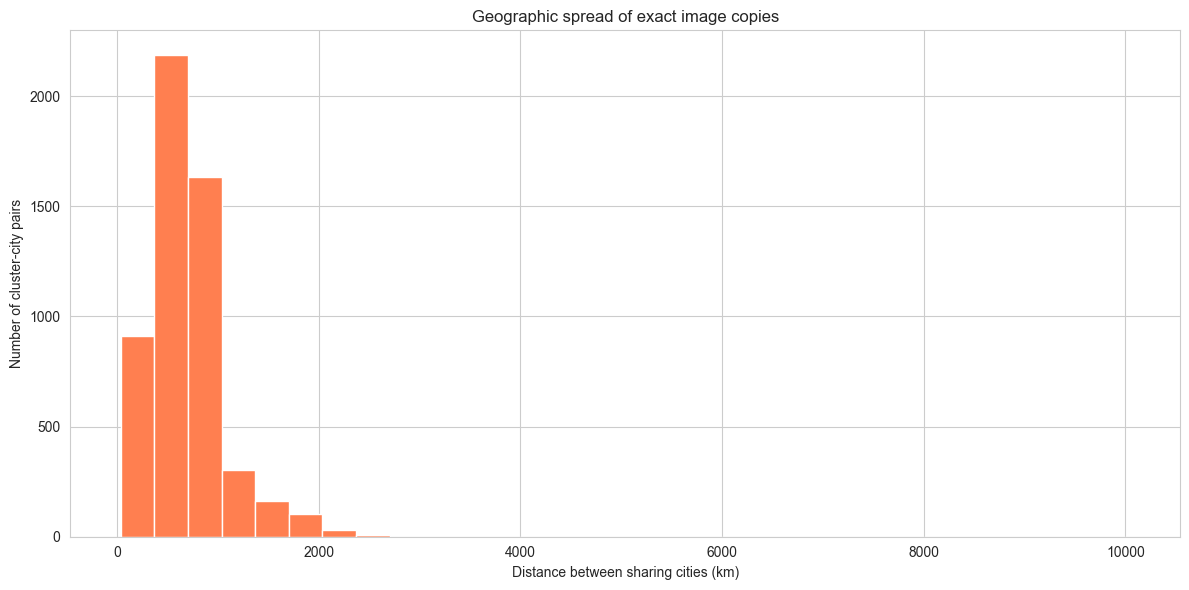

In [121]:
fig, ax = plt.subplots()
ax.hist(pair_distances['distance_km'], bins=30, color='coral', edgecolor='white')
ax.set_xlabel('Distance between sharing cities (km)')
ax.set_ylabel('Number of cluster-city pairs')
ax.set_title('Geographic spread of exact image copies')
plt.tight_layout()
plt.show()

### 2c. Did long-distance copying change over time?

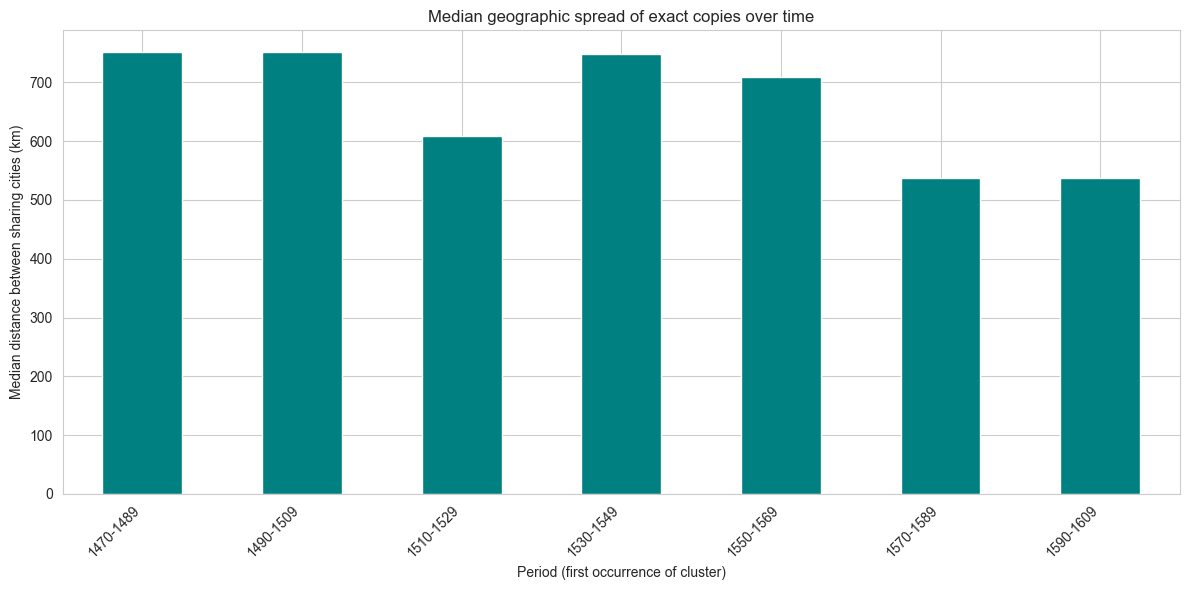

In [122]:
# Attach year_interval to pair_distances using the year_min of the cluster
interval_bins = [1469, 1489, 1509, 1529, 1549, 1569, 1589, 1609, 1650]
interval_labels = ['1470-1489','1490-1509','1510-1529','1530-1549',
                   '1550-1569','1570-1589','1590-1609','1610-1647']
pair_distances['interval'] = pd.cut(pair_distances['year_min'],
                                     bins=interval_bins, labels=interval_labels, right=True)

fig, ax = plt.subplots()
interval_dist = pair_distances.groupby('interval', observed=True)['distance_km'].median()
interval_dist.plot(kind='bar', ax=ax, color='teal')
ax.set_xlabel('Period (first occurrence of cluster)')
ax.set_ylabel('Median distance between sharing cities (km)')
ax.set_title('Median geographic spread of exact copies over time')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

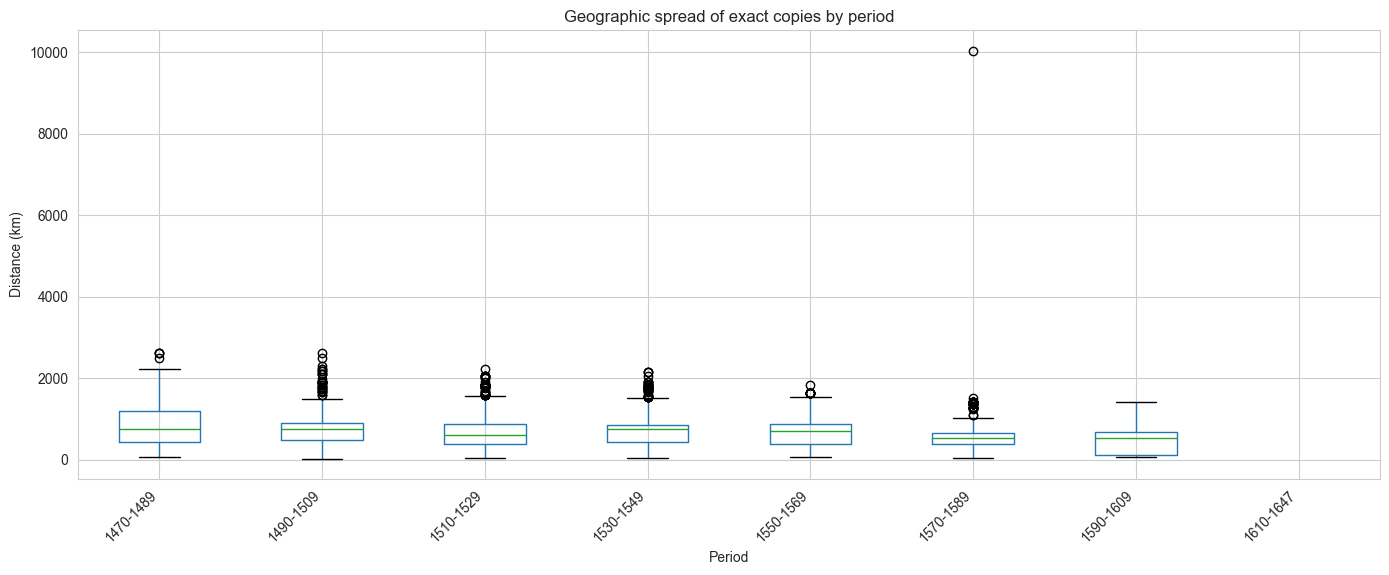

In [123]:
# Box plot for more nuance
fig, ax = plt.subplots(figsize=(14,6))
pair_distances.boxplot(column='distance_km', by='interval', ax=ax)
ax.set_xlabel('Period')
ax.set_ylabel('Distance (km)')
ax.set_title('Geographic spread of exact copies by period')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2d. Place-to-place exact copy flow matrix

In [124]:
# How many shared clusters between each pair of cities?
from collections import defaultdict

flow = defaultdict(int)
for _, row in pair_distances.iterrows():
    key = tuple(sorted([row['place1'], row['place2']]))
    flow[key] += 1

flow_df = pd.DataFrame([(k[0], k[1], v) for k, v in flow.items()],
                        columns=['city1', 'city2', 'shared_clusters'])
flow_df = flow_df.sort_values('shared_clusters', ascending=False)
print('Top 20 city pairs by shared exact clusters:')
flow_df.head(20)

Top 20 city pairs by shared exact clusters:


,city1,city2,shared_clusters
1,Paris,Venice,340
43,Lyon,Venice,212
56,Lyon,Rome,155
42,Lyon,Paris,131
9,Rome,Venice,129
97,Antwerp,Paris,109
57,Lyon,Saint Gervais,109
53,Geneva,Saint Gervais,100
50,Geneva,Lyon,100
59,Rome,Saint Gervais,100


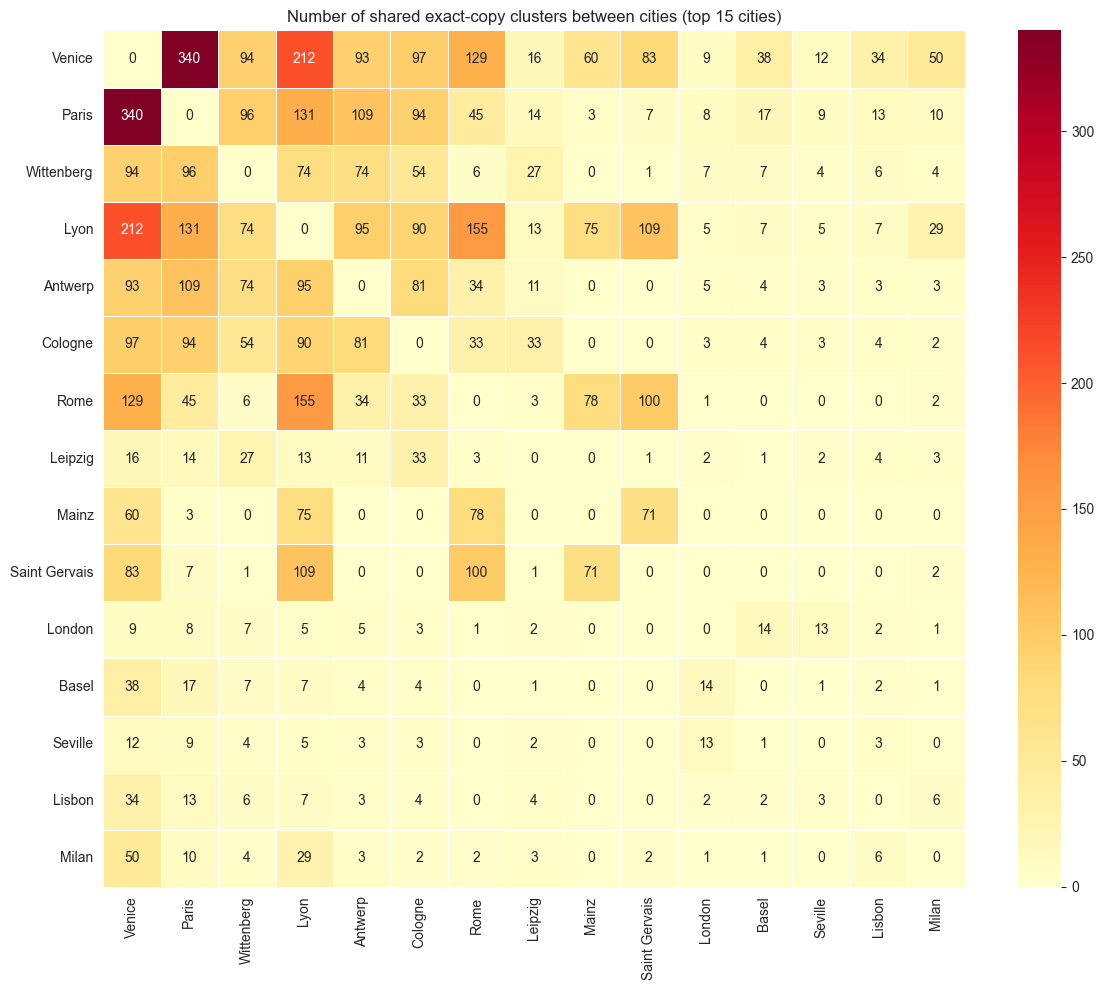

In [125]:
# Pivot to heatmap (top 15 cities by presence)
top_cities = img_unique['place'].value_counts().head(15).index.tolist()
matrix_data = flow_df[
    flow_df['city1'].isin(top_cities) & flow_df['city2'].isin(top_cities)
]

# Build symmetric matrix
hm = pd.DataFrame(0, index=top_cities, columns=top_cities)
for _, r in matrix_data.iterrows():
    hm.loc[r['city1'], r['city2']] = r['shared_clusters']
    hm.loc[r['city2'], r['city1']] = r['shared_clusters']

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(hm, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=.5)
ax.set_title('Number of shared exact-copy clusters between cities (top 15 cities)')
plt.tight_layout()
plt.show()

### 2e. Publisher-level analysis of exact copies

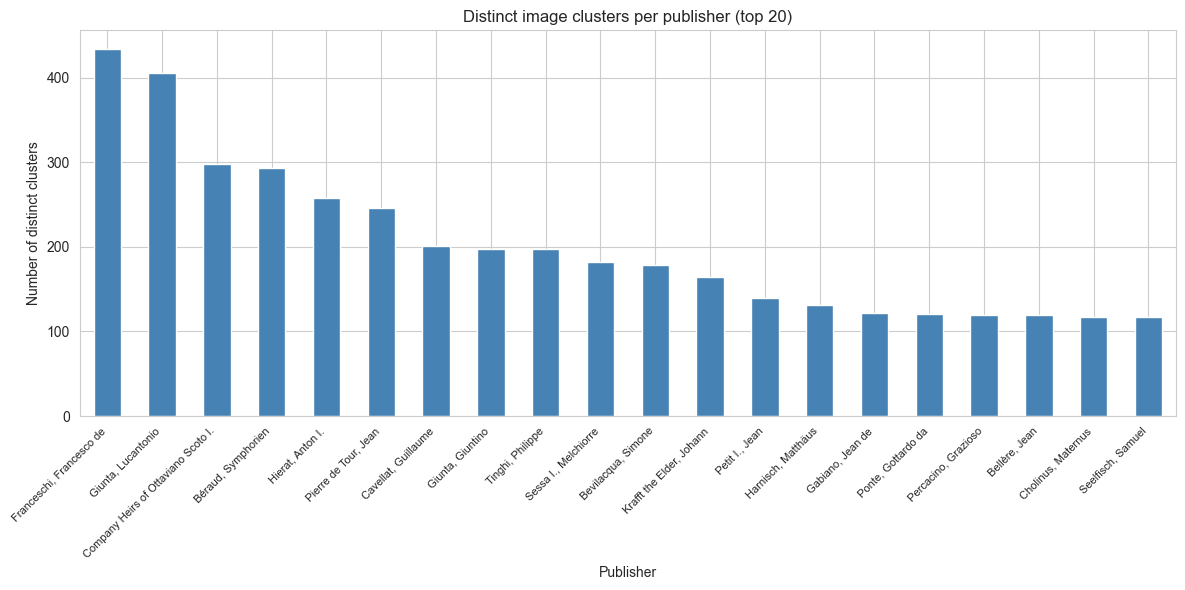

In [126]:
# Merge image data with book data to get publisher info
img_book = img_unique.merge(
    book_df[['book', 'publishers', 'printers', 'place', 'year']],
    left_on='book', right_on='book', how='left',
    suffixes=('', '_book')
)

# Number of clusters per publisher
pub_clusters = (
    img_book.groupby('publishers')['cluster_name']
    .nunique()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 6))
pub_clusters.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Publisher')
ax.set_ylabel('Number of distinct clusters')
ax.set_title('Distinct image clusters per publisher (top 20)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## 3. Content Keyword (CK) Similarity

Here we compare books not by exact copies but by **how similar their content-keyword profiles are**.  
Each book is represented as a binary vector over all CKs → cosine similarity gives a measure of "thematic closeness".

### 3a. Build book–CK vectors

In [127]:
# Each row in img_df is (image, ck, book). Collect all CKs per book.
book_cks = img_df.groupby('bid')['cks'].apply(lambda x: sorted(x.dropna().unique().tolist())).reset_index()
book_cks.columns = ['bid', 'ck_list']

# Binarize
mlb = MultiLabelBinarizer()
ck_matrix = mlb.fit_transform(book_cks['ck_list'])
ck_df = pd.DataFrame(ck_matrix, index=book_cks['bid'], columns=mlb.classes_)

print('CK matrix shape (books × keywords):', ck_df.shape)
ck_df.head(3)

CK matrix shape (books × keywords): (342, 168)


,CK_07 Spheres,CK_08 Spheres,CK_09 Spheres,CK_10 Spheres,CK_11 Spheres,CK_12 Spheres,CK_Additions on Definitions of the Sphere,CK_Alhidade,CK_Apparent Size of Stars,CK_Arithmetical Proportions,...,CK_Venus Lines and Motion,CK_Venus Orbit,CK_Venus Proportional Minutes,CK_Venus Symbols,CK_Visibility of Half of the Sky from the Central Earth,CK_Visibility of Stars from Varied Locations,CK_Water Clock,CK_Winds,CK_Zodiac,CK_Zodiac man
bid,,,,,,,,,,,,,,,,,,,,,
1594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1597,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1611,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Similarity matrix: (342, 342)


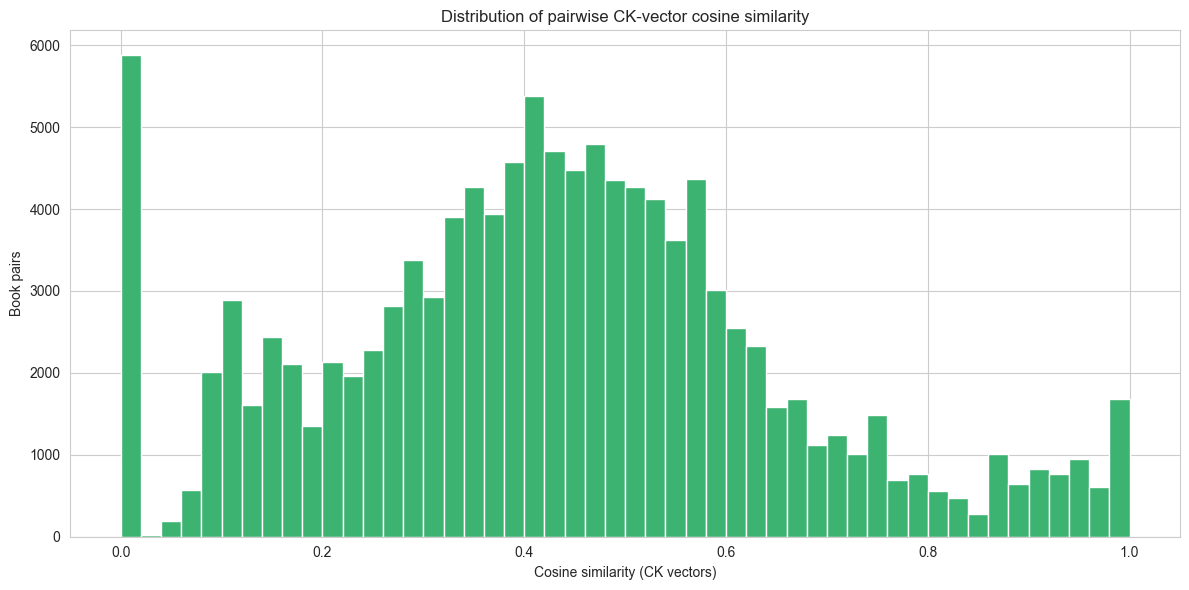

In [128]:
# Compute all-pairs cosine similarity
sim_matrix = cosine_similarity_matrix(ck_matrix)
sim_df = pd.DataFrame(sim_matrix, index=book_cks['bid'], columns=book_cks['bid'])
print('Similarity matrix:', sim_df.shape)

# Distribution of similarities (excluding self-similarity)
np.fill_diagonal(sim_matrix, np.nan)
sims = sim_matrix[~np.isnan(sim_matrix)]
fig, ax = plt.subplots()
ax.hist(sims, bins=50, color='mediumseagreen', edgecolor='white')
ax.set_xlabel('Cosine similarity (CK vectors)')
ax.set_ylabel('Book pairs')
ax.set_title('Distribution of pairwise CK-vector cosine similarity')
plt.tight_layout()
plt.show()

### 3b. Attach place / year / publisher to CK similarity pairs

In [129]:
# Build metadata table per bid
meta = (
    img_unique[['bid', 'place', 'year', 'year_interval', 'latitude', 'longitude']]
    .drop_duplicates('bid')
    .set_index('bid')
)

# Build long-form pairwise similarity table (upper triangle)
bids = book_cks['bid'].values
n = len(bids)
pair_rows = []
for i in range(n):
    for j in range(i+1, n):
        sim = sim_matrix[i, j]
        if np.isnan(sim):
            continue
        b1, b2 = bids[i], bids[j]
        m1 = meta.loc[b1] if b1 in meta.index else {}
        m2 = meta.loc[b2] if b2 in meta.index else {}
        row = {
            'bid1': b1, 'bid2': b2,
            'ck_similarity': sim,
            'place1': m1.get('place') if isinstance(m1, pd.Series) else None,
            'place2': m2.get('place') if isinstance(m2, pd.Series) else None,
            'year1': m1.get('year') if isinstance(m1, pd.Series) else None,
            'year2': m2.get('year') if isinstance(m2, pd.Series) else None,
        }
        # compute geographic distance if coords available
        try:
            d = haversine(m1['latitude'], m1['longitude'], m2['latitude'], m2['longitude'])
            row['distance_km'] = d
        except:
            row['distance_km'] = np.nan
        pair_rows.append(row)

ck_pairs = pd.DataFrame(pair_rows)
ck_pairs['same_place'] = ck_pairs['place1'] == ck_pairs['place2']
ck_pairs['year_diff'] = (ck_pairs['year1'] - ck_pairs['year2']).abs()
print('CK pair table:', ck_pairs.shape)
ck_pairs.describe()

CK pair table: (58311, 10)


,bid1,bid2,ck_similarity,year1,year2,distance_km,year_diff
count,58311.000000,58311.000000,58311.000000,58311.000000,58311.000000,53301.000000,58311.000000
mean,1826.352609,2052.600607,0.429645,1552.618563,1562.603660,735.590541,41.788599
std,150.073700,173.200121,0.225866,38.030466,34.442287,817.854813,30.724402
min,1594.000000,1597.000000,0.000000,1472.000000,1472.000000,0.000000,0.000000
25%,1712.000000,1900.000000,0.285299,1520.000000,1547.000000,391.812014,17.000000
50%,1808.000000,2091.000000,0.428174,1552.000000,1565.000000,715.289345,36.000000
75%,1899.000000,2217.000000,0.561445,1578.000000,1585.000000,869.503815,61.000000
max,2280.000000,2281.000000,1.000001,1647.000000,1647.000000,10260.904285,175.000000


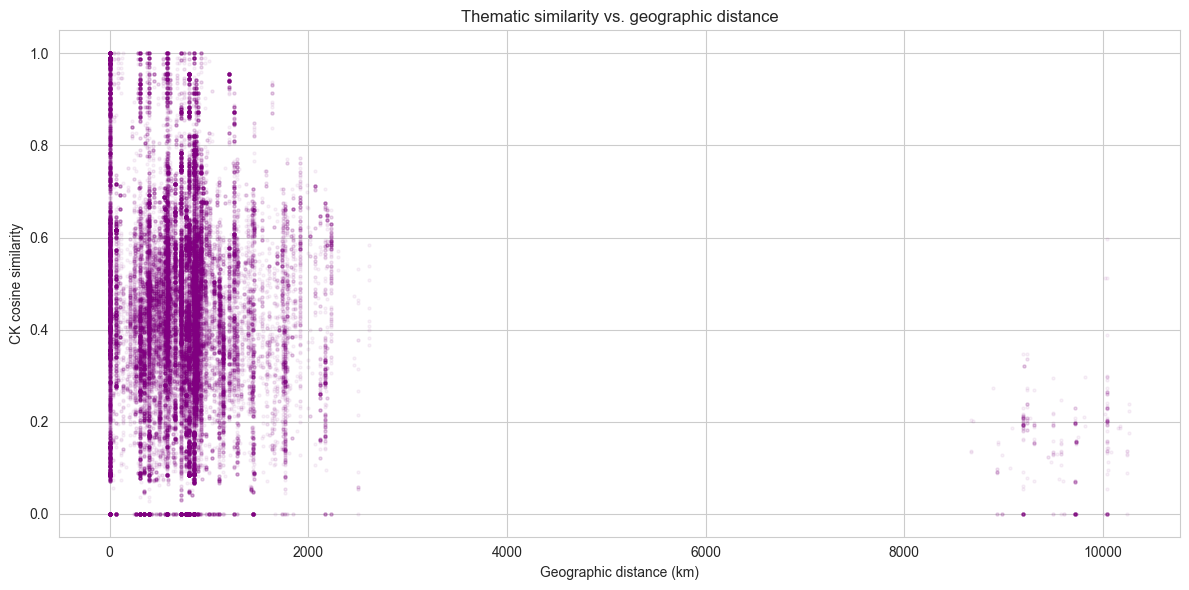

In [130]:
# Is there a relationship between CK similarity and geographic distance?
subset = ck_pairs.dropna(subset=['distance_km', 'ck_similarity'])

fig, ax = plt.subplots()
ax.scatter(subset['distance_km'], subset['ck_similarity'], alpha=0.05, s=5, color='purple')
ax.set_xlabel('Geographic distance (km)')
ax.set_ylabel('CK cosine similarity')
ax.set_title('Thematic similarity vs. geographic distance')
plt.tight_layout()
plt.show()

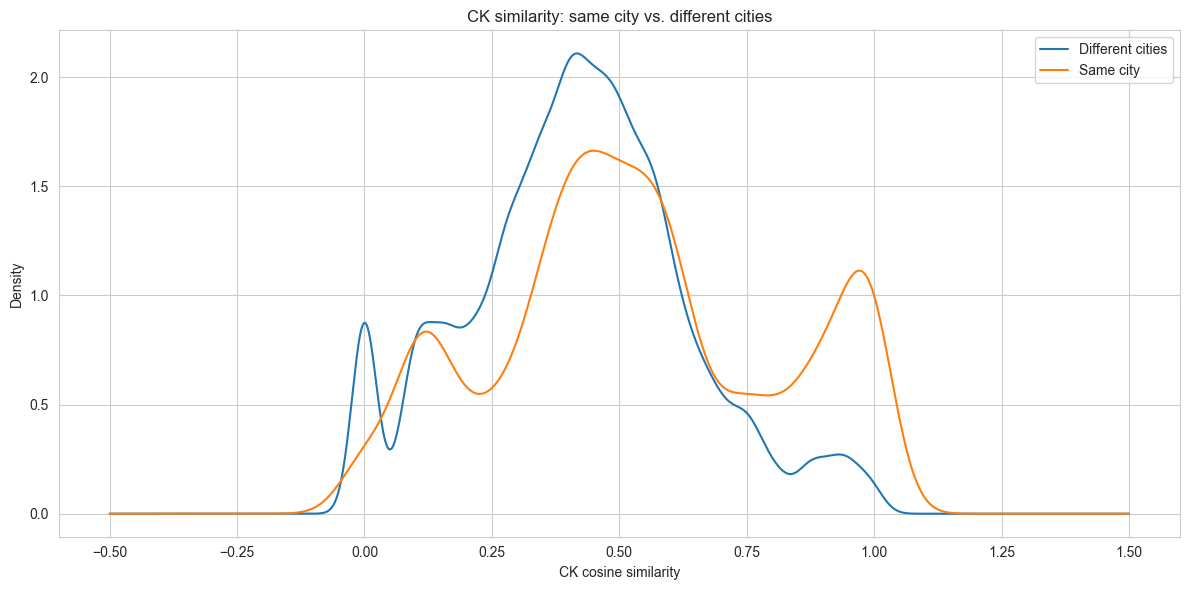

In [131]:
# Same city vs different city CK similarity
fig, ax = plt.subplots()
ck_pairs.groupby('same_place')['ck_similarity'].plot(kind='density', ax=ax, legend=True)
ax.set_xlabel('CK cosine similarity')
ax.set_title('CK similarity: same city vs. different cities')
ax.legend(['Different cities', 'Same city'])
plt.tight_layout()
plt.show()

### 3c. CK similarity over time (by year_interval)

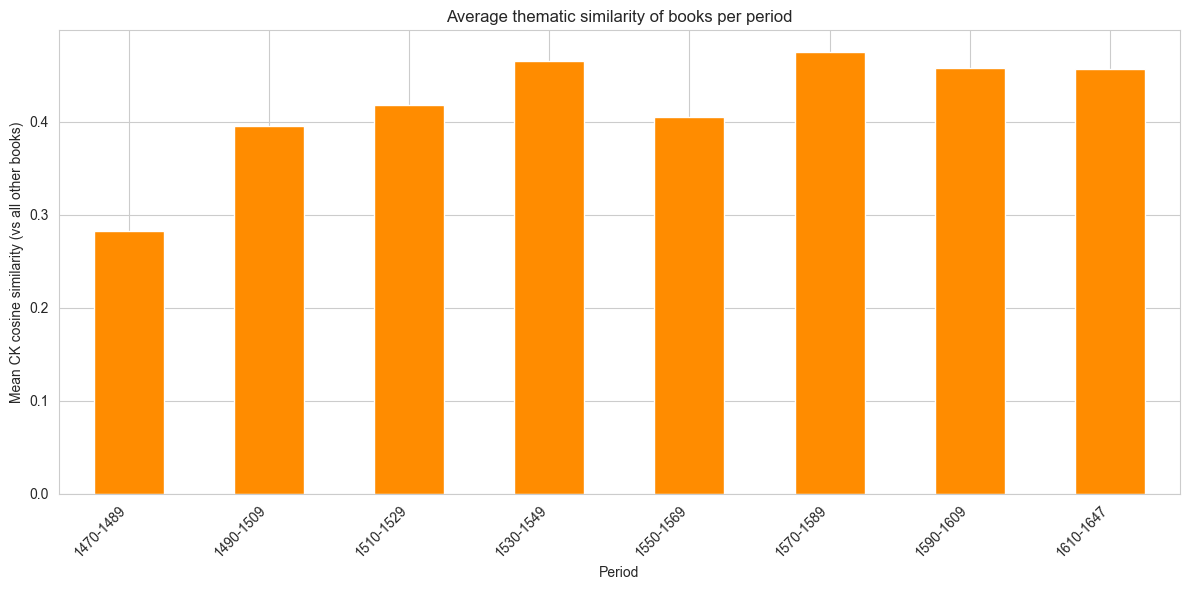

In [132]:
# Attach year_interval (use year1 as reference)
interval_bins = [1469, 1489, 1509, 1529, 1549, 1569, 1589, 1609, 1650]
interval_labels = ['1470-1489','1490-1509','1510-1529','1530-1549',
                   '1550-1569','1570-1589','1590-1609','1610-1647']
ck_pairs['interval1'] = pd.cut(ck_pairs['year1'].dropna(),
                                bins=interval_bins, labels=interval_labels, right=True)

fig, ax = plt.subplots()
avg_sim = ck_pairs.groupby('interval1', observed=True)['ck_similarity'].mean()
avg_sim.plot(kind='bar', ax=ax, color='darkorange')
ax.set_xlabel('Period')
ax.set_ylabel('Mean CK cosine similarity (vs all other books)')
ax.set_title('Average thematic similarity of books per period')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Comparing Exact-Copy vs. CK Sharing

For books that share exact copies, is their CK similarity also higher?

In [133]:
# Build a set of (bid1, bid2) pairs that share at least one cluster
cluster_to_bids = img_unique.groupby('cluster_name')['bid'].apply(set)

exact_pairs = set()
for bids_in_cluster in cluster_to_bids:
    for b1, b2 in combinations(sorted(bids_in_cluster), 2):
        exact_pairs.add((b1, b2))

print(f'Book pairs sharing at least one exact cluster: {len(exact_pairs)}')

# Tag ck_pairs with whether they share exact copies
ck_pairs['share_exact'] = ck_pairs.apply(
    lambda r: (r['bid1'], r['bid2']) in exact_pairs or (r['bid2'], r['bid1']) in exact_pairs,
    axis=1
)

print(ck_pairs['share_exact'].value_counts())

Book pairs sharing at least one exact cluster: 23001
share_exact
False    35310
True     23001
Name: count, dtype: int64


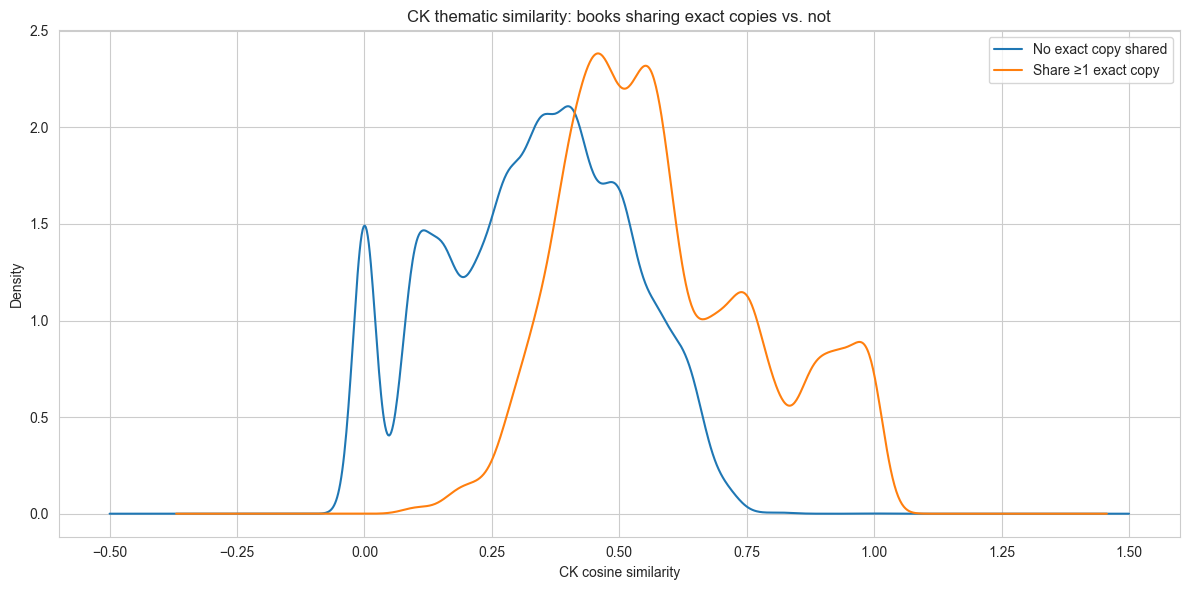

In [134]:
fig, ax = plt.subplots()
ck_pairs.groupby('share_exact')['ck_similarity'].plot(kind='density', ax=ax)
ax.set_xlabel('CK cosine similarity')
ax.set_title('CK thematic similarity: books sharing exact copies vs. not')
ax.legend(['No exact copy shared', 'Share ≥1 exact copy'])
plt.tight_layout()
plt.show()

In [135]:
# Summary stats
ck_pairs.groupby('share_exact')['ck_similarity'].describe()

,count,mean,std,min,25%,50%,75%,max
share_exact,,,,,,,,
False,35310.0,0.328488,0.182008,0.000000,0.182574,0.342381,0.467707,1.000000
True,23001.0,0.584937,0.196606,0.087039,0.439286,0.549227,0.722691,1.000001


---
## SECTION: Focused — Exact Image Sharing Between Books

**Six graphs exploring:**
1. How common is exact image sharing across books?
2. What conditions predict sharing: same printer? publisher? city?
3. Distance distribution and time gap for cross-city sharing
4. Remote exceptions → candidates for book travel
5. Geographic map of sharing flows
6. How many images shared per pair, and does distance matter?

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from math import radians, cos, sin, asin, sqrt
from collections import Counter
from matplotlib.lines import Line2D

img_df = pd.read_csv('/Users/nogashlomi/projects/Image_data/dissertation/full_image_data_feb_25.csv')
book_df = pd.read_csv('/Users/nogashlomi/projects/Image_data/dissertation/full_book_data_feb_25.csv')

# Deduplicate: one row per unique (image, cluster, book)
img_u = img_df.drop_duplicates(subset=['images', 'cluster_name', 'bid']).copy()

# Merge book metadata into image table
img_u = img_u.merge(book_df[['bid','publishers','printers','place','year']],
                    on='bid', how='left', suffixes=('','_book'))

# Place coordinates lookup
coords = (img_df[['place','latitude','longitude']]
          .dropna().drop_duplicates('place').set_index('place'))

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1,lon1,lat2,lon2 = map(radians,[lat1,lon1,lat2,lon2])
    a = sin((lat2-lat1)/2)**2 + cos(lat1)*cos(lat2)*sin((lon2-lon1)/2)**2
    return 2*R*asin(sqrt(a))

print('Data loaded.')
print(f'Books: {img_u["bid"].nunique()}  |  Clusters: {img_u["cluster_name"].nunique()}  |  Publishers: {img_u["publishers"].nunique()}')


Data loaded.
Books: 342  |  Clusters: 3563  |  Publishers: 155


### Graph 0 — How many images are in each cluster?

Many images were never copied exactly and thus belong to a cluster of size 1. This graph shows the overall distribution of cluster sizes.

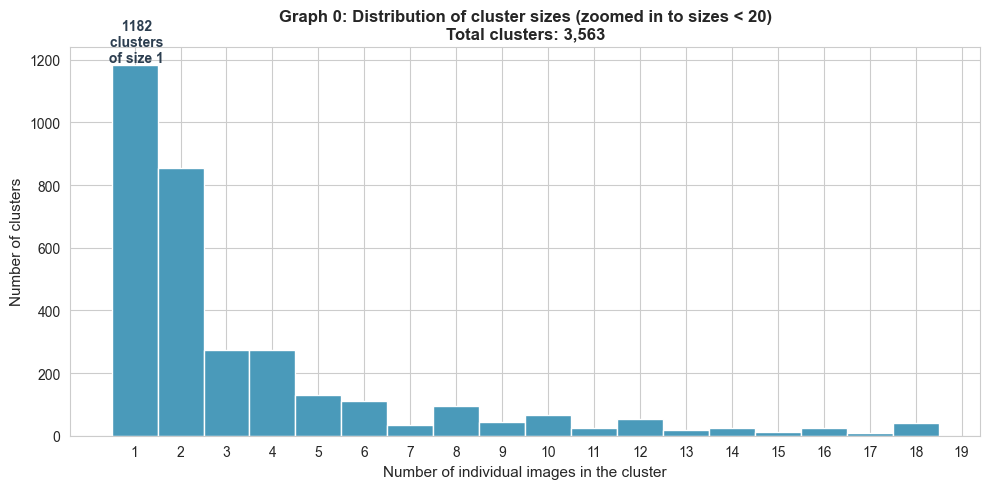

Clusters with exactly 1 image (never exactly copied): 1,182 (33.2%)
Clusters with >1 image: 2,381 (66.8%)
Largest cluster has 425 images.


In [137]:
# Count how many total images (rows) are in each cluster
# Note: using the raw image dataframe to see total occurrences
cluster_sizes = img_df['cluster_name'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bins = range(1, 20)
ax.hist(cluster_sizes[cluster_sizes < 20], bins=bins, color='#4a9aba', edgecolor='white', align='left')
ax.set_xticks(range(1, 20))

# Add text annotation for the huge number of size-1 clusters
size_1_count = sum(cluster_sizes == 1)
if size_1_count > 0:
    ax.text(1, size_1_count, f' {size_1_count}\n clusters\n of size 1', 
            va='bottom', ha='center', fontsize=10, color='#2c3e50', fontweight='bold')

ax.set_xlabel('Number of individual images in the cluster', fontsize=11)
ax.set_ylabel('Number of clusters', fontsize=11)
ax.set_title('Graph 0: Distribution of cluster sizes (zoomed in to sizes < 20)\n'
             f'Total clusters: {len(cluster_sizes):,}', fontsize=12, fontweight='bold')

plt.tight_layout(); plt.show()

print(f"Clusters with exactly 1 image (never exactly copied): {size_1_count:,} ({100 * size_1_count / len(cluster_sizes):.1f}%)")
print(f"Clusters with >1 image: {len(cluster_sizes) - size_1_count:,} ({100 * (len(cluster_sizes) - size_1_count) / len(cluster_sizes):.1f}%)")
print(f"Largest cluster has {cluster_sizes.max():,} images.")


### Graph 1 — How common is exact image sharing?

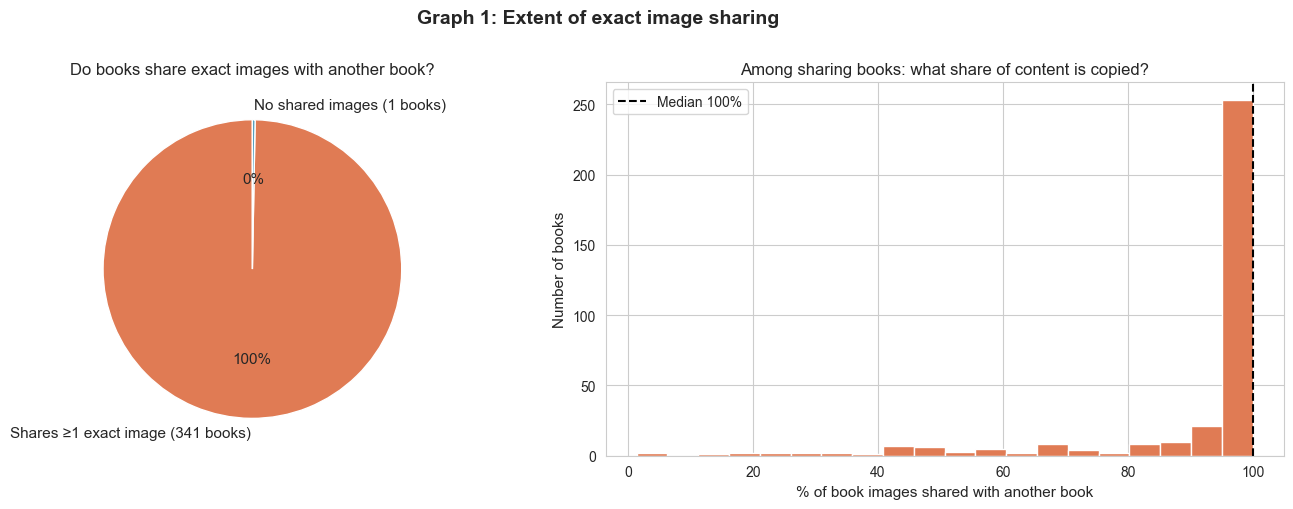

Clusters shared in >1 book: 1726 / 3563 = 48.4%
Books sharing ≥1 image: 341 / 342


In [138]:
cluster_book_count = img_u.groupby('cluster_name')['bid'].nunique()
shared_clusters = cluster_book_count[cluster_book_count > 1]

book_shared = img_u.copy()
book_shared['is_shared'] = book_shared['cluster_name'].isin(shared_clusters.index)
book_summary = book_shared.groupby('bid').agg(
    total_clusters=('cluster_name','nunique'),
    shared_clusters=('cluster_name', lambda x: x[book_shared.loc[x.index,'is_shared']].nunique())
).reset_index()
book_summary['pct_shared'] = 100*book_summary['shared_clusters']/book_summary['total_clusters']
book_summary['has_any_shared'] = book_summary['shared_clusters'] > 0
share_counts = book_summary['has_any_shared'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    [share_counts.get(True,0), share_counts.get(False,0)],
    labels=[f'Shares ≥1 exact image ({share_counts.get(True,0)} books)',
            f'No shared images ({share_counts.get(False,0)} books)'],
    colors=['#e07b54','#4a9aba'], autopct='%1.0f%%', startangle=90,
    textprops={'fontsize':11}
)
axes[0].set_title('Do books share exact images with another book?', fontsize=12)

df_has = book_summary[book_summary['has_any_shared']]
axes[1].hist(df_has['pct_shared'], bins=20, color='#e07b54', edgecolor='white')
axes[1].axvline(df_has['pct_shared'].median(), color='black', linestyle='--',
                label=f'Median {df_has["pct_shared"].median():.0f}%')
axes[1].set_xlabel('% of book images shared with another book', fontsize=11)
axes[1].set_ylabel('Number of books', fontsize=11)
axes[1].set_title('Among sharing books: what share of content is copied?', fontsize=12)
axes[1].legend()

plt.suptitle('Graph 1: Extent of exact image sharing', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()
print(f'Clusters shared in >1 book: {len(shared_clusters)} / {len(cluster_book_count)} = {100*len(shared_clusters)/len(cluster_book_count):.1f}%')
print(f'Books sharing ≥1 image: {share_counts.get(True,0)} / {len(book_summary)}')


### Build sharing pairs table (used by graphs 2–6)

In [139]:
# All book-pairs that share a cluster, with conditions
cluster_to_bids = img_u.groupby('cluster_name')['bid'].apply(lambda x: sorted(x.unique().tolist()))
bid_meta = img_u[['bid','publishers','printers','place','year']].drop_duplicates('bid').set_index('bid')

rows = []
for cluster, bids_in in cluster_to_bids.items():
    if len(bids_in) < 2: continue
    for b1, b2 in combinations(bids_in, 2):
        if b1 not in bid_meta.index or b2 not in bid_meta.index: continue
        m1, m2 = bid_meta.loc[b1], bid_meta.loc[b2]
        p1, p2 = m1['place'], m2['place']
        dist = np.nan
        if p1 in coords.index and p2 in coords.index:
            dist = haversine(coords.loc[p1,'latitude'], coords.loc[p1,'longitude'],
                             coords.loc[p2,'latitude'], coords.loc[p2,'longitude'])
        rows.append({'cluster':cluster,'b1':b1,'b2':b2,
                     'same_publisher': m1['publishers']==m2['publishers'],
                     'same_printer':   m1['printers']  ==m2['printers'],
                     'same_place':     p1==p2,
                     'year_diff': abs(m1['year']-m2['year']) if pd.notna(m1['year']) and pd.notna(m2['year']) else np.nan,
                     'distance_km':dist, 'place1':p1, 'place2':p2})

pairs = pd.DataFrame(rows)

# Dedup to one row per unique book pair (may share multiple clusters)
pairs['pair_key'] = [tuple(sorted([a,b])) for a,b in zip(pairs.b1,pairs.b2)]
pairs_dedup = pairs.drop_duplicates('pair_key').copy()

# Simplified: publishers stay in one city, so 'diff city + same publisher' is noise.
# Use 3 categories: same city (any pub), diff city
def cond_label(r):
    if r['same_place']:   return 'Same city'
    return 'Different city'
pairs_dedup['condition'] = pairs_dedup.apply(cond_label, axis=1)

# Count clusters per book pair
n_clusters_per_pair = pairs.groupby('pair_key')['cluster'].count().rename('n_shared_clusters')
pairs_dedup = pairs_dedup.merge(n_clusters_per_pair, on='pair_key', how='left')

print(f'Unique sharing book pairs: {len(pairs_dedup)}')
print(pairs_dedup['condition'].value_counts().to_string())


Unique sharing book pairs: 23001
condition
Different city    19189
Same city          3812


### Graph 2 — Under what conditions do books share exact images?

### Graph 2a — The Publisher Paradox: Book Pairs vs. Total Images

While 97% of *book pairs* that share an image are by different publishers, if we count the **total volume of individual images shared**, we see that same-publisher pairs share nearly 3 times as many images on average (reprints). However, because there are so many more different-publisher connections, different-publisher sharing still accounts for 93% of the total volume.

In [ ]:
df_pub = pairs_dedup.groupby('same_publisher').agg(
    n_pairs=('pair_key', 'count'),
    n_images=('n_shared_clusters', 'sum')
).reset_index()
df_pub['label'] = df_pub['same_publisher'].map({True: 'Same Publisher', False: 'Different Publisher'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(df_pub['n_pairs'], labels=df_pub['label'], autopct='%1.1f%%', colors=['#c0392b', '#f39c12'])
axes[0].set_title('By NUMBER OF BOOK PAIRS')

axes[1].pie(df_pub['n_images'], labels=df_pub['label'], autopct='%1.1f%%', colors=['#c0392b', '#f39c12'])
axes[1].set_title('By TOTAL VOLUME OF IMAGES SHARED')

plt.suptitle('Graph 2a: How much sharing is internal reprinting vs. external copying?', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

mean_same = pairs_dedup[pairs_dedup['same_publisher']]['n_shared_clusters'].mean()
mean_diff = pairs_dedup[~pairs_dedup['same_publisher']]['n_shared_clusters'].mean()
print(f"Average images shared when Same Publisher: {mean_same:.1f} images per pair")
print(f"Average images shared when Diff Publisher: {mean_diff:.1f} images per pair")


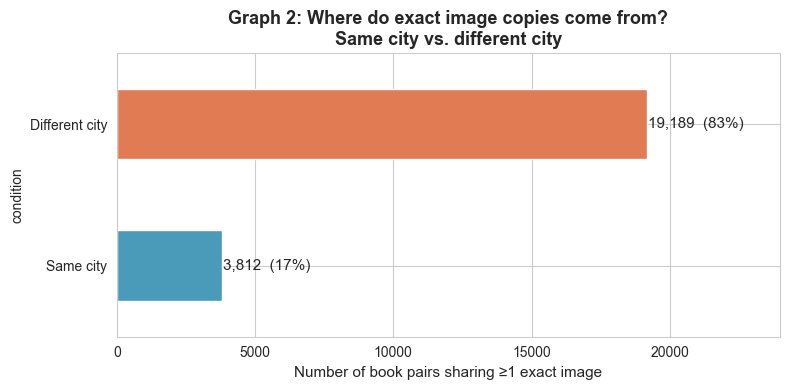

In [140]:
cond_counts = pairs_dedup.groupby('condition')['n_shared_clusters'].sum()
colors_cond = ['#4a9aba', '#e07b54']

fig, ax = plt.subplots(figsize=(8, 4))
cond_counts.sort_values().plot(kind='barh', ax=ax, color=colors_cond, edgecolor='white')
for i,(val,label) in enumerate(zip(cond_counts.sort_values().values, cond_counts.sort_values().index)):
    ax.text(val+20, i, f'{val:,}  ({100*val/pairs_dedup["n_shared_clusters"].sum():.0f}%)', va='center', fontsize=11)
ax.set_xlabel('Total volume of individual images shared', fontsize=11)
ax.set_title('Graph 2: Where do exact image copies come from? (VOLUME OF IMAGES)\nSame city vs. different city',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, cond_counts.max()*1.25)
plt.tight_layout(); plt.show()




### Graph 3 — Cross-city sharing: distance and time gap

When books in different cities share the same image — how far apart are they, and how much time passed?

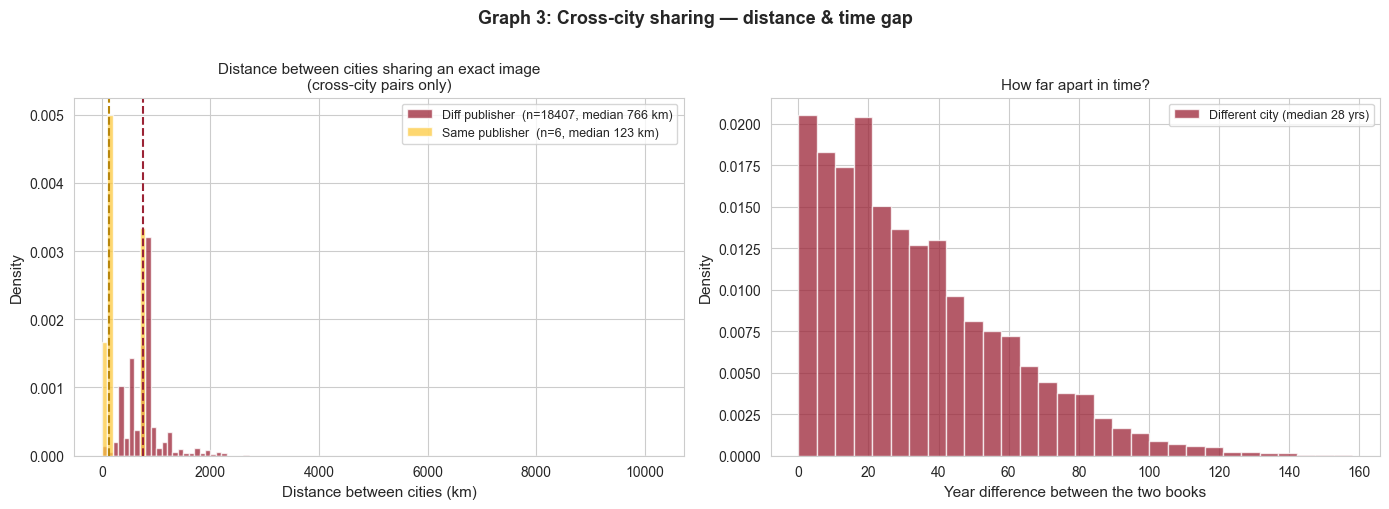

In [141]:
cross = pairs_dedup[~pairs_dedup['same_place']].dropna(subset=['distance_km'])
same_pub = cross[cross['same_publisher']]['distance_km']
diff_pub = cross[~cross['same_publisher']]['distance_km']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = list(range(0, int(cross['distance_km'].max())+200, 100))
axes[0].hist(diff_pub, bins=bins, alpha=0.75, color='#9b2335', density=True,
             label=f'Diff publisher  (n={len(diff_pub)}, median {diff_pub.median():.0f} km)')
axes[0].hist(same_pub, bins=bins, alpha=0.75, color='#fdca40', density=True,
             label=f'Same publisher  (n={len(same_pub)}, median {same_pub.median():.0f} km)')
axes[0].axvline(diff_pub.median(), color='#9b2335', linestyle='--', lw=1.5)
axes[0].axvline(same_pub.median(), color='#b8860b', linestyle='--', lw=1.5)
axes[0].set_xlabel('Distance between cities (km)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Distance between cities sharing an exact image\n(cross-city pairs only)', fontsize=11)
axes[0].legend(fontsize=9)

cross_t = cross.dropna(subset=['year_diff'])
for cond, color in [('Different city','#9b2335')]:
    sub = cross_t[cross_t['condition']==cond]['year_diff']
    if len(sub):
        axes[1].hist(sub, bins=30, alpha=0.75, color=color, density=True,
                     label=f'{cond} (median {sub.median():.0f} yrs)')
axes[1].set_xlabel('Year difference between the two books', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('How far apart in time?', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle('Graph 3: Cross-city sharing — distance & time gap',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### Graph 4 — Remote exceptions: exact sharing > 800 km

These are the strongest evidence for books traveling far and being copied from distant originals.

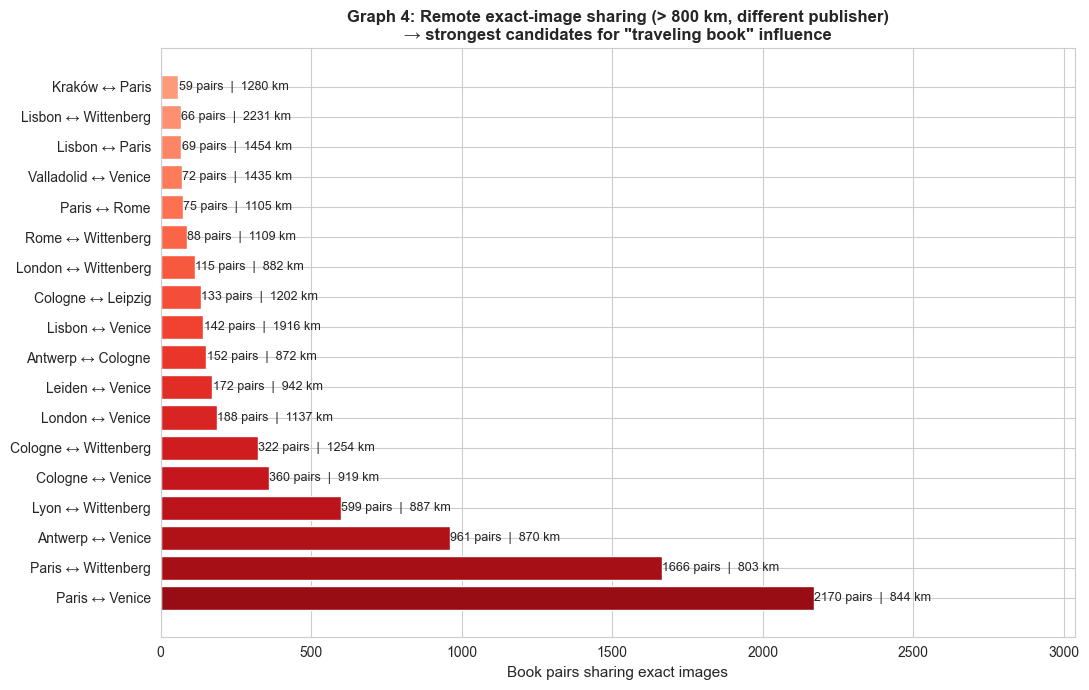

Total remote exception pairs: 8982


In [142]:
remote = cross[cross['distance_km'] > 800]  # All cross-city pairs > 800 km

exc_flow = Counter()
for _,r in remote.iterrows():
    key = tuple(sorted([r['place1'], r['place2']]))
    exc_flow[key] += 1

exc_df = pd.DataFrame([(k[0],k[1],v) for k,v in exc_flow.most_common(18)],
                       columns=['city1','city2','n_pairs'])
exc_df['pair'] = exc_df['city1'] + ' ↔ ' + exc_df['city2']
exc_df['dist'] = exc_df.apply(
    lambda r: haversine(coords.loc[r.city1,'latitude'], coords.loc[r.city1,'longitude'],
                        coords.loc[r.city2,'latitude'], coords.loc[r.city2,'longitude'])
    if r.city1 in coords.index and r.city2 in coords.index else np.nan, axis=1)

fig, ax = plt.subplots(figsize=(11, 7))
cmap = plt.cm.Reds(np.linspace(0.35, 0.9, len(exc_df)))
bars = ax.barh(exc_df['pair'], exc_df['n_pairs'], color=cmap[::-1], edgecolor='white')
for bar, (_, r) in zip(bars, exc_df.iterrows()):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{r["n_pairs"]} pairs  |  {r["dist"]:.0f} km', va='center', fontsize=9)
ax.set_xlabel('Book pairs sharing exact images', fontsize=11)
ax.set_title('Graph 4: Remote exact-image sharing (> 800 km, different publisher)\n'
             '→ strongest candidates for "traveling book" influence',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, exc_df['n_pairs'].max()*1.4)
plt.tight_layout(); plt.show()
print(f'Total remote exception pairs: {len(remote)}')



### Graph 5 — Geographic map: top city-pair sharing flows

Only the **top 25 pairs** by number of shared clusters. Line thickness = shared clusters. All shown pairs are different-city.

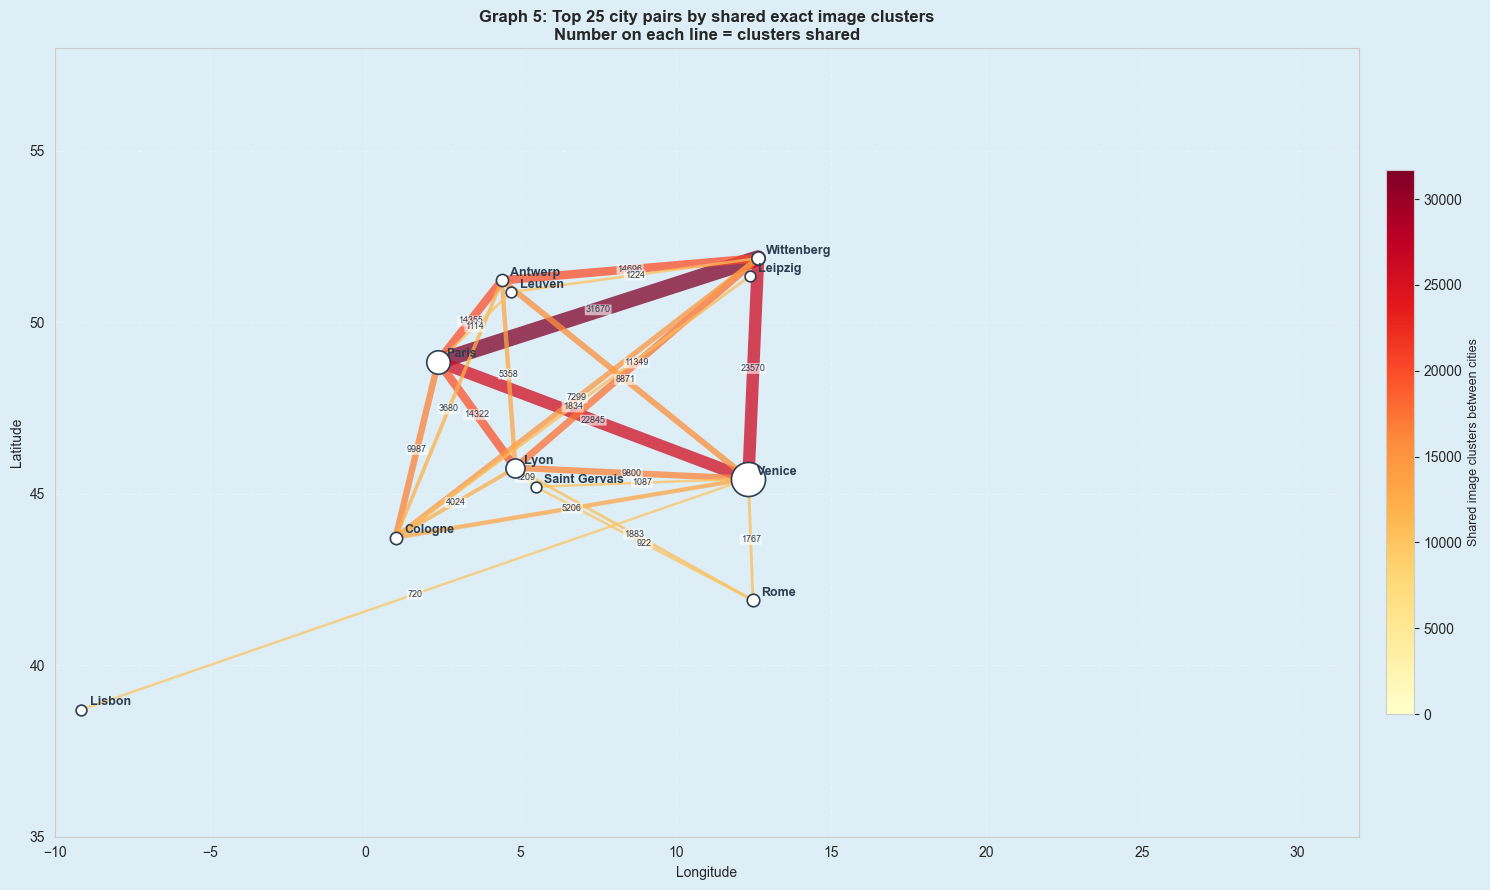

In [143]:
# Count shared clusters between every city pair (all cross-city)
flow = {}
for _,r in pairs.iterrows():
    if r['place1'] == r['place2']: continue
    key = tuple(sorted([r['place1'], r['place2']]))
    flow[key] = flow.get(key, 0) + 1

top_pairs = sorted(flow.items(), key=lambda x: -x[1])[:25]
max_n = top_pairs[0][1]

fig, ax = plt.subplots(figsize=(15, 9))
ax.set_facecolor('#ddeef6')
fig.patch.set_facecolor('#ddeef6')
ax.set_xlim(-10, 32); ax.set_ylim(35, 58)
ax.grid(True, linestyle='--', alpha=0.25, color='white')

# Draw arcs - color by volume
cmap = plt.cm.YlOrRd
for (p1, p2), n in top_pairs:
    if p1 not in coords.index or p2 not in coords.index: continue
    x1,y1 = coords.loc[p1,'longitude'], coords.loc[p1,'latitude']
    x2,y2 = coords.loc[p2,'longitude'], coords.loc[p2,'latitude']
    lw = 1.5 + 10 * n / max_n
    color = cmap(0.3 + 0.7 * n / max_n)
    ax.plot([x1,x2],[y1,y2], color=color, lw=lw, alpha=0.75,
            solid_capstyle='round', zorder=3)
    # Label the midpoint with the count
    mx, my = (x1+x2)/2, (y1+y2)/2
    ax.text(mx, my, str(n), fontsize=6.5, color='#2c3e50',
            ha='center', va='center', zorder=5,
            bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6, ec='none'))

# Identify cities that appear in top pairs
active_cities = set(p for pair,_ in top_pairs for p in pair)
city_sizes = img_u.groupby('place')['cluster_name'].nunique()
for place in active_cities:
    if place not in coords.index: continue
    lon,lat = coords.loc[place,'longitude'], coords.loc[place,'latitude']
    s = max(60, city_sizes.get(place,10) * 0.4)
    ax.scatter(lon, lat, s=s, color='white', edgecolor='#2c3e50', zorder=6, lw=1.2)
    ax.annotate(place.replace(' (Main)',''), (lon,lat),
                textcoords='offset points', xytext=(6,3),
                fontsize=9, fontweight='bold', color='#2c3e50', zorder=7)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, max_n))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Shared image clusters between cities', fontsize=9)

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Graph 5: Top 25 city pairs by shared exact image clusters\n'
             'Number on each line = clusters shared', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


### Graph 6 — Ranked bar chart: which city pairs share the most exact images?

Simple reading: the more clusters shared, the stronger the evidence of copying. Distance shown for reference.

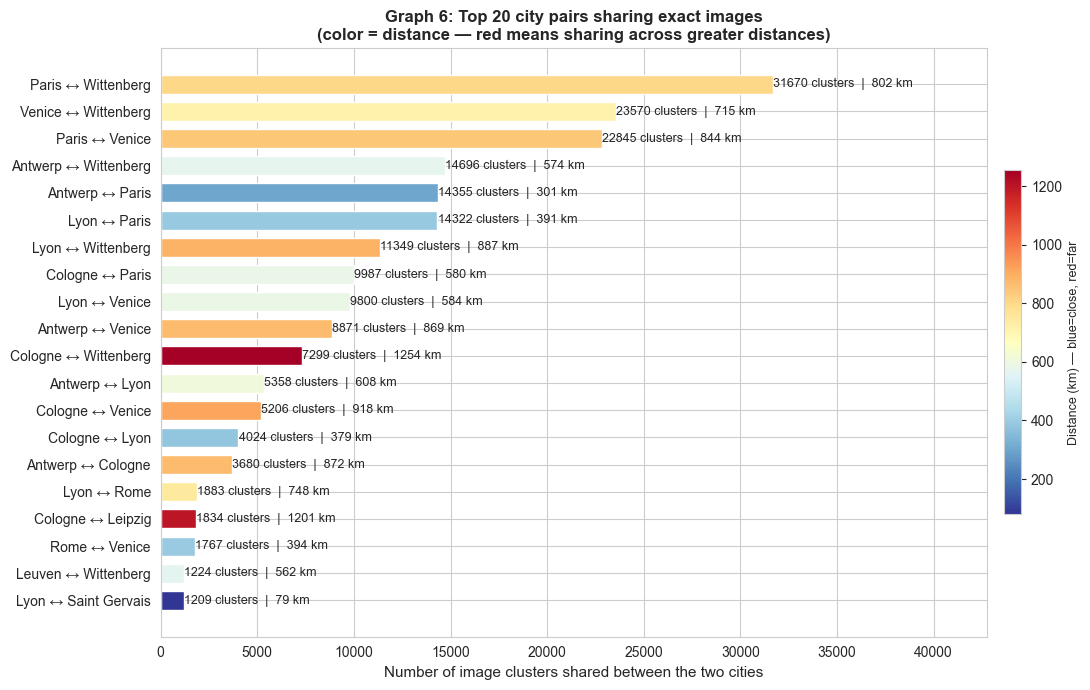

In [144]:
top_n = 20
flow_df = pd.DataFrame(
    [(k[0], k[1], v) for k,v in flow.items()],
    columns=['city1','city2','shared_clusters']
).sort_values('shared_clusters', ascending=False).head(top_n)

flow_df['pair'] = flow_df['city1'] + ' ↔ ' + flow_df['city2']
flow_df['dist_km'] = flow_df.apply(
    lambda r: int(haversine(coords.loc[r.city1,'latitude'], coords.loc[r.city1,'longitude'],
                            coords.loc[r.city2,'latitude'], coords.loc[r.city2,'longitude']))
    if r.city1 in coords.index and r.city2 in coords.index else 0, axis=1)

# Color bars by distance (closer = blue, farther = red)
norm = plt.Normalize(flow_df['dist_km'].min(), flow_df['dist_km'].max())
bar_colors = plt.cm.RdYlBu_r(norm(flow_df['dist_km'].values))

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(flow_df['pair'], flow_df['shared_clusters'],
               color=bar_colors, edgecolor='white', height=0.7)
for bar, (_, r) in zip(bars, flow_df.iterrows()):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{r["shared_clusters"]} clusters  |  {r["dist_km"]} km',
            va='center', fontsize=9)

# Colorbar for distance
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlBu_r, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Distance (km) — blue=close, red=far', fontsize=9)

ax.set_xlabel('Number of image clusters shared between the two cities', fontsize=11)
ax.set_xlim(0, flow_df['shared_clusters'].max() * 1.35)
ax.invert_yaxis()
ax.set_title('Graph 6: Top 20 city pairs sharing exact images\n'
             '(color = distance — red means sharing across greater distances)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


### Graph 7 — Normalizing for City Size: What are the strongest proportional connections?

Because huge printing centres like Paris and Venice printed so many books, they naturally share the most absolute numbers of images (as seen in Graphs 5 and 6). To find the strongest *dependencies*, we normalize using the **Overlap Coefficient**.

Overlap = `shared_clusters / size_of_smaller_city`

If a small city prints 50 images, and all 50 are also found in Paris, the overlap is 1.0 (100%). This reveals which cities completely imported their visual program from another hub.

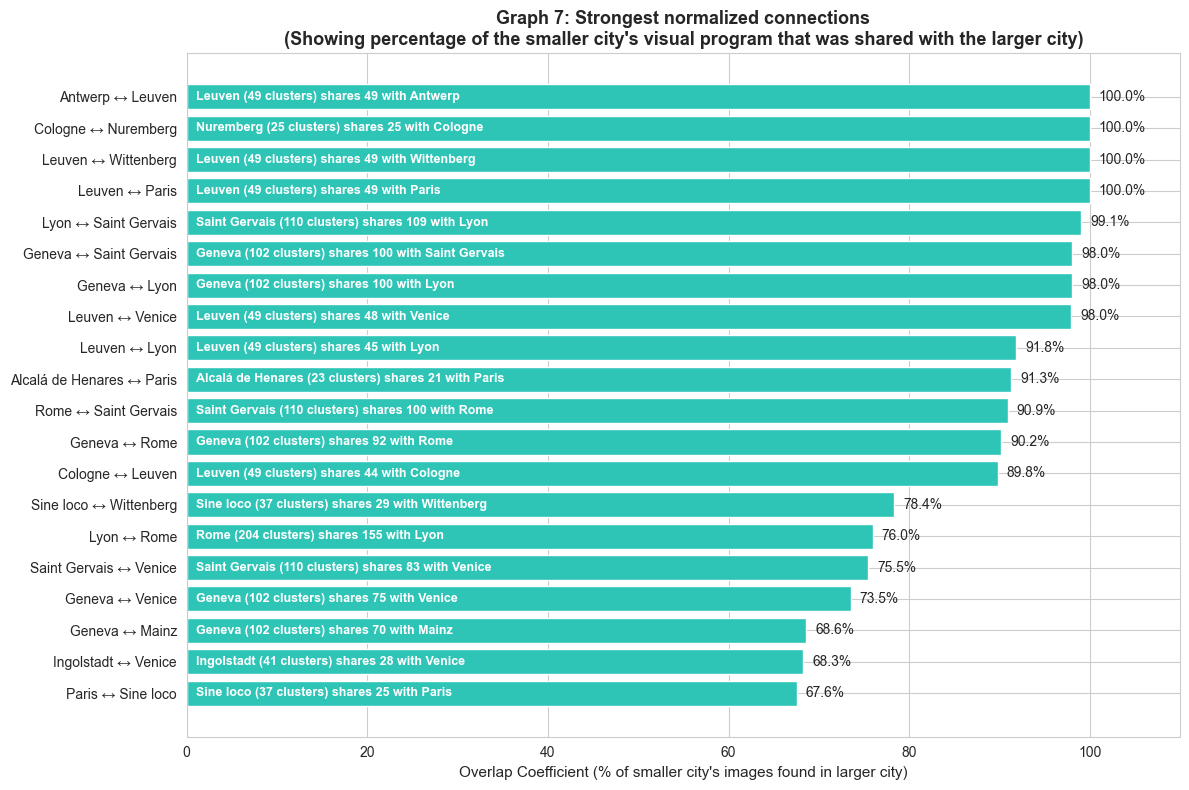

In [145]:
city_clusters = img_u.groupby('place')['cluster_name'].apply(set).to_dict()
city_sizes = {place: len(clusters) for place, clusters in city_clusters.items()}

# Filter to established printing centres (e.g., ≥ 20 unique clusters) to avoid noise from 1-book cities
valid_cities = {p: s for p, s in city_sizes.items() if s >= 20}

results = []
for c1, c2 in combinations(valid_cities.keys(), 2):
    s1 = city_clusters[c1]
    s2 = city_clusters[c2]
    shared = len(s1.intersection(s2))
    if shared == 0: continue

    overlap = shared / min(len(s1), len(s2))
    results.append({
        'pair': f"{c1} ↔ {c2}",
        'overlap': overlap * 100,  # as percentage
        'shared': shared,
        'smaller_city': c1 if len(s1) < len(s2) else c2,
        'larger_city': c2 if len(s1) < len(s2) else c1,
        'smaller_size': min(len(s1), len(s2)),
        'larger_size': max(len(s1), len(s2))
    })

df_overlap = pd.DataFrame(results).sort_values('overlap', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(df_overlap['pair'], df_overlap['overlap'], color='#2ec4b6', edgecolor='white')

for bar, (_, r) in zip(bars, df_overlap.iterrows()):
    ax.text(1, bar.get_y() + bar.get_height()/2,
            f"{r['smaller_city']} ({r['smaller_size']} clusters) shares {r['shared']} with {r['larger_city']}",
            va='center', color='white', fontweight='bold', fontsize=9)
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{r['overlap']:.1f}%", va='center', fontsize=10)

ax.set_xlabel('Overlap Coefficient (% of smaller city\'s images found in larger city)', fontsize=11)
ax.set_xlim(0, 110)
ax.invert_yaxis()  # largest at top
ax.set_title('Graph 7: Strongest normalized connections\n'
             '(Showing percentage of the smaller city\'s visual program that was shared with the larger city)', 
             fontsize=13, fontweight='bold')

plt.tight_layout(); plt.show()


---
## SECTION: City Roles — Hubs, Spokes, and Network Centrality

**Questions:**
1. Do the massive hubs innovate (produce unique images) or just copy?
2. Which cities are the most central to the network (sharing with the highest number of *other places*)?
3. What does the directed *hub-and-spoke* network look like?

### Graph 8 — Innovation vs Copying: Which cities have the most unique images?

A 'unique' image is a cluster that only ever appears in one city. If a city prints 500 images but 450 of them are shared elsewhere, the city is a massive node but perhaps not the sole innovator. If a city prints 200 images and 150 are unique, it introduced a lot of new visual material.

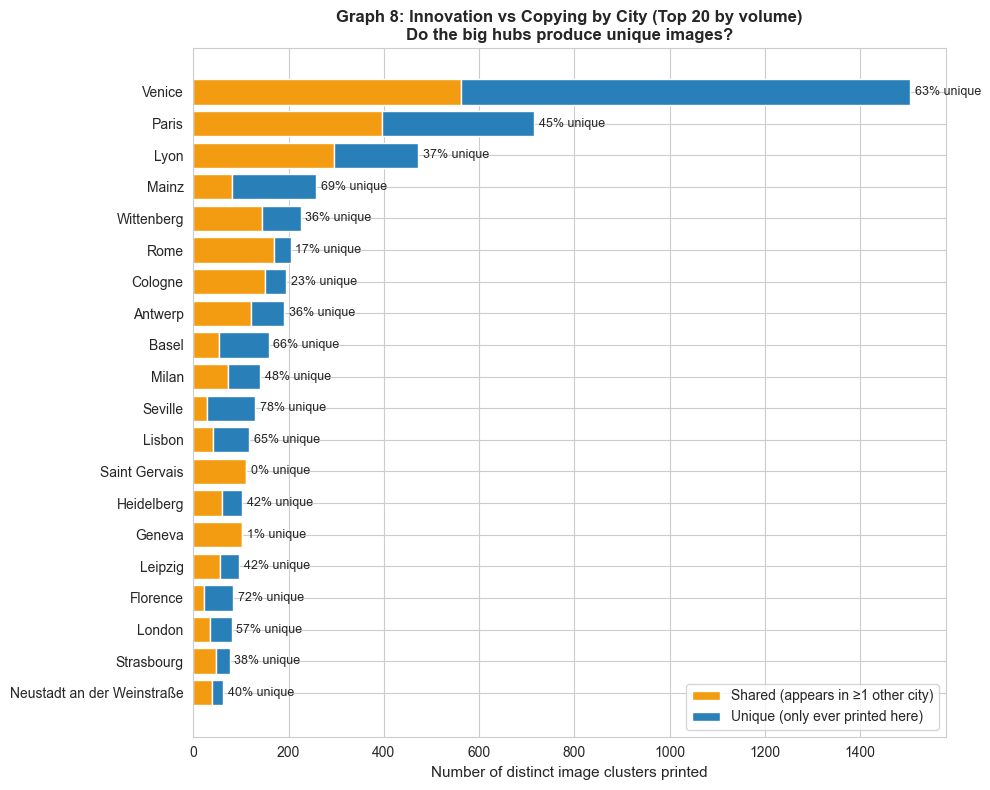

In [146]:
import networkx as nx

# Which clusters are globally unique to one city?
cluster_places = img_u.groupby('cluster_name')['place'].apply(lambda x: set(x.dropna()))
unique_clusters = set(c for c, places in cluster_places.items() if len(places) == 1)

# For each city, how many total clusters and how many unique?
city_clusters = img_u.groupby('place')['cluster_name'].apply(set)
city_stats = []
for city, clusters in city_clusters.items():
    if len(clusters) < 5: continue
    n_unique = len(clusters.intersection(unique_clusters))
    n_shared = len(clusters) - n_unique
    city_stats.append({
        'city': city, 'total': len(clusters), 
        'unique': n_unique, 'shared': n_shared,
        'perc_unique': n_unique / len(clusters) * 100
    })

df_innov = pd.DataFrame(city_stats).sort_values('total', ascending=True)
# Only plot top 20 by volume to keep readable
df_innov_top = df_innov.tail(20).copy()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_innov_top['city'], df_innov_top['shared'], color='#f39c12', label='Shared (appears in ≥1 other city)')
ax.barh(df_innov_top['city'], df_innov_top['unique'], left=df_innov_top['shared'], color='#2980b9', label='Unique (only ever printed here)')

for i, r in enumerate(df_innov_top.itertuples()):
    ax.text(r.total + 10, i, f"{r.perc_unique:.0f}% unique", va='center', fontsize=9)

ax.set_xlabel('Number of distinct image clusters printed', fontsize=11)
ax.set_title('Graph 8: Innovation vs Copying by City (Top 20 by volume)\n'
             'Do the big hubs produce unique images?', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()


### Graph 9 — Degree Centrality: Who shares with the most other cities?

This counts the *number of different cities* that a city shares at least one exact image with. A high degree centrality means the city is a cross-roads of visual material.

In [147]:
city_degrees = defaultdict(set)
for places in cluster_places.values():
    if len(places) > 1:
        plist = list(places)
        for i in range(len(plist)):
            for j in range(i+1, len(plist)):
                city_degrees[plist[i]].add(plist[j])
                city_degrees[plist[j]].add(plist[i])

degree_df = pd.DataFrame([{'city': k, 'n_partners': len(v)} for k, v in city_degrees.items()])
degree_df = degree_df.sort_values('n_partners', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(degree_df['city'], degree_df['n_partners'], color='#8e44ad', edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Number of partner cities', fontsize=11)
ax.set_title('Graph 9: Degree Centrality (Top 20)\nHow many different cities does each city share images with?',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


TypeError: 'numpy.ndarray' object is not callable

### Graph 10 — Hub-and-Spoke Directed Network Map

This network graph plots **strong dependencies**. An arrow goes from **Hub → Spoke** if the Spoke city took **more than 50%** of its entire visual program from the Hub.
Node size = total images printed by the city.

In [ ]:
# Build directed edges based on high overlap (dependency)
dependencies = []
valid_cities = {p: s for p, s in df_innov.set_index('city')['total'].items() if s >= 10}

for c1, c2 in combinations(valid_cities.keys(), 2):
    s1 = city_clusters[c1]
    s2 = city_clusters[c2]
    shared = len(s1.intersection(s2))
    if shared == 0: continue
    
    # Overlap threshold: 50% dependency
    if shared / len(s1) >= 0.5:
        dependencies.append({'hub': c2, 'spoke': c1, 'weight': shared/len(s1)})
    if shared / len(s2) >= 0.5:
        dependencies.append({'hub': c1, 'spoke': c2, 'weight': shared/len(s2)})

G = nx.DiGraph()
for c in valid_cities:
    G.add_node(c, size=valid_cities[c])

for d in dependencies:
    G.add_edge(d['hub'], d['spoke'], weight=d['weight'])

# Remove isolated nodes (cities that neither give >50% nor take >50%)
isolated = list(nx.isolates(G))
G.remove_nodes_from(isolated)

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)

# Node sizes (scaled)
node_sizes = [G.nodes[n]['size'] * 3 for n in G.nodes()]

# Draw hubs vs spokes differently
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
node_colors = ['#e74c3c' if out_degrees[n] > 1 else ('#3498db' if in_degrees[n] > 0 else '#95a5a6') for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, edgecolors='white', alpha=0.9, ax=ax)

# Draw directed edges
edges = G.edges()
weights = [G[u][v]['weight'] * 2 for u, v in edges]
nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, edge_color='#7f8c8d',
                       arrowsize=15, arrowstyle='-|>', connectionstyle='arc3,rad=0.1', ax=ax)

# Labels with custom positioning
for node, (x, y) in pos.items():
    ax.text(x, y + 0.05, node, fontsize=10, fontweight='bold', ha='center', va='bottom',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=12, label='Major Hub (Provider to multiple cities)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=12, label='Spoke (Takes >50% from a hub)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)

ax.set_title("Graph 10: Directed Network of Visual Dependencies\n"
             "Arrow indicates Hub → Spoke (Spoke sources > 50% of its images from the Hub). Node size = Total images printed", 
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout(); plt.show()


---
## SECTION: City Roles — Hubs, Spokes, and Network Centrality

**Questions:**
1. Do the massive hubs innovate (produce unique images) or just copy?
2. Which cities are the most central to the network (sharing with the highest number of *other places*)?
3. What does the directed *hub-and-spoke* network look like?

### Graph 8 — Innovation vs Copying: Which cities have the most unique images?

A 'unique' image is a cluster that only ever appears in one city. If a city prints 500 images but 450 of them are shared elsewhere, the city is a massive node but perhaps not the sole innovator. If a city prints 200 images and 150 are unique, it introduced a lot of new visual material.

In [ ]:
import networkx as nx
from collections import defaultdict

# Which clusters are globally unique to one city?
cluster_places = img_u.groupby('cluster_name')['place'].apply(lambda x: set(x.dropna()))
unique_clusters = set(c for c, places in cluster_places.items() if len(places) == 1)

# For each city, how many total clusters and how many unique?
city_clusters = img_u.groupby('place')['cluster_name'].apply(set)
city_stats = []
for city, clusters in city_clusters.items():
    if len(clusters) < 5: continue
    n_unique = len(clusters.intersection(unique_clusters))
    n_shared = len(clusters) - n_unique
    city_stats.append({
        'city': city, 'total': len(clusters), 
        'unique': n_unique, 'shared': n_shared,
        'perc_unique': n_unique / len(clusters) * 100
    })

df_innov = pd.DataFrame(city_stats).sort_values('total', ascending=True)
# Only plot top 20 by volume to keep readable
df_innov_top = df_innov.tail(20).copy()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_innov_top['city'], df_innov_top['shared'], color='#f39c12', label='Shared (appears in ≥1 other city)')
ax.barh(df_innov_top['city'], df_innov_top['unique'], left=df_innov_top['shared'], color='#2980b9', label='Unique (only ever printed here)')

for i, r in enumerate(df_innov_top.itertuples()):
    ax.text(r.total + 10, i, f"{r.perc_unique:.0f}% unique", va='center', fontsize=9)

ax.set_xlabel('Number of distinct image clusters printed', fontsize=11)
ax.set_title('Graph 8: Innovation vs Copying by City (Top 20 by volume)\n'
             'Do the big hubs produce unique images?', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()


### Graph 9 — Degree Centrality: Who shares with the most other cities?

This counts the *number of different cities* that a city shares at least one exact image with. A high degree centrality means the city is a cross-roads of visual material.

In [ ]:
city_degrees = defaultdict(set)
for places in cluster_places.values():
    if len(places) > 1:
        plist = list(places)
        for i in range(len(plist)):
            for j in range(i+1, len(plist)):
                city_degrees[plist[i]].add(plist[j])
                city_degrees[plist[j]].add(plist[i])

degree_df = pd.DataFrame([{'city': k, 'n_partners': len(v)} for k, v in city_degrees.items()])
degree_df = degree_df.sort_values('n_partners', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(degree_df['city'], degree_df['n_partners'], color='#8e44ad', edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Number of partner cities', fontsize=11)
ax.set_title('Graph 9: Degree Centrality (Top 20)\nHow many different cities does each city share images with?',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


### Graph 10 — Hub-and-Spoke Directed Network Map

This network graph plots **strong dependencies**. An arrow goes from **Hub → Spoke** if the Spoke city took **more than 50%** of its entire visual program from the Hub.
Node size = total images printed by the city.

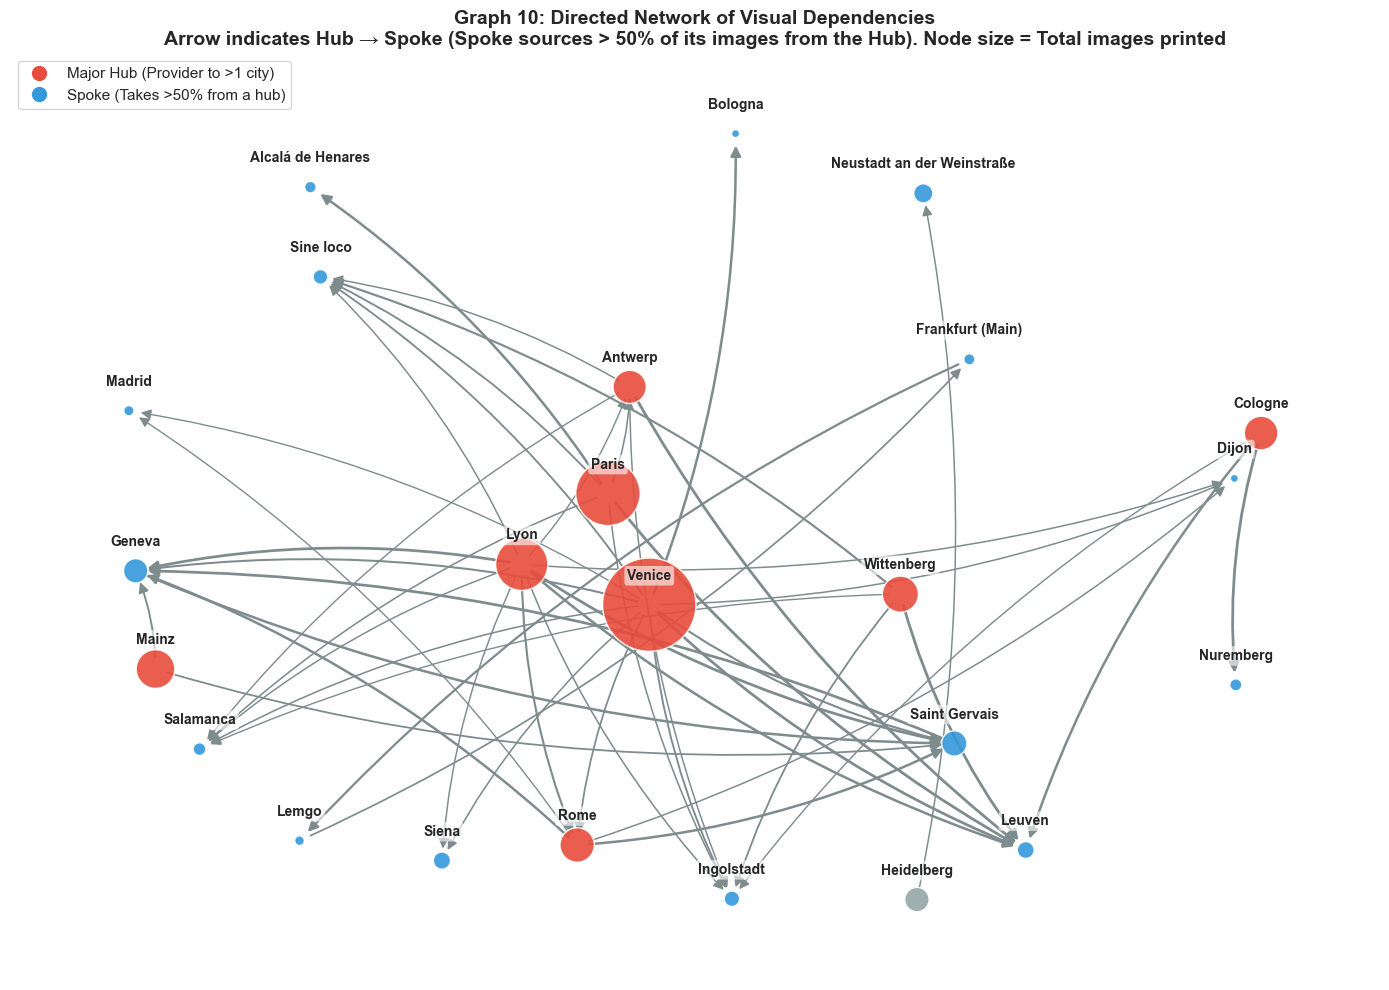

In [148]:
# Build directed edges based on high overlap (dependency)
from itertools import combinations

dependencies = []
valid_cities = {p: s for p, s in df_innov.set_index('city')['total'].items() if s >= 10}

for c1, c2 in combinations(valid_cities.keys(), 2):
    s1 = city_clusters[c1]
    s2 = city_clusters[c2]
    shared = len(s1.intersection(s2))
    if shared == 0: continue
    
    # Overlap threshold: 50% dependency
    if shared / len(s1) >= 0.5:
        dependencies.append({'spoke': c1, 'hub': c2, 'weight': shared/len(s1)})
    if shared / len(s2) >= 0.5:
        dependencies.append({'spoke': c2, 'hub': c1, 'weight': shared/len(s2)})

G = nx.DiGraph()
for c in valid_cities:
    G.add_node(c, size=valid_cities[c])

for d in dependencies:
    G.add_edge(d['hub'], d['spoke'], weight=d['weight'])

# Remove isolated nodes (cities that neither give >50% nor take >50%)
isolated = list(nx.isolates(G))
G.remove_nodes_from(isolated)

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)

# Node sizes (scaled)
node_sizes = [G.nodes[n]['size'] * 3 for n in G.nodes()]

# Draw hubs vs spokes differently
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
node_colors = ['#e74c3c' if out_degrees[n] > 1 else ('#3498db' if in_degrees[n] > 0 else '#95a5a6') for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, edgecolors='white', alpha=0.9, ax=ax)

# Draw directed edges
edges = G.edges()
weights = [G[u][v]['weight'] * 2 for u, v in edges]
nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, edge_color='#7f8c8d',
                       arrowsize=15, arrowstyle='-|>', connectionstyle='arc3,rad=0.1', ax=ax)

# Labels with custom positioning
for node, (x, y) in pos.items():
    ax.text(x, y + 0.05, node, fontsize=10, fontweight='bold', ha='center', va='bottom',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=12, label='Major Hub (Provider to >1 city)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=12, label='Spoke (Takes >50% from a hub)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)

ax.set_title("Graph 10: Directed Network of Visual Dependencies\n"
             "Arrow indicates Hub → Spoke (Spoke sources > 50% of its images from the Hub). Node size = Total images printed", 
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout(); plt.show()
